### 💻  Assignment 3 - Predictive Analysis (Part 1- Regression) for Laptop Price Dataset


**Information about the group and report**

* Group Number: 58 \\
* Name of Team Members: Yasmine Zoubdi and Anoushka Jawale \\
* Student Numbers : 300170464 and 300233148 \\

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.impute import KNNImputer
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split, KFold
from sklearn.neighbors import LocalOutlierFactor


##  💻 Introduction

In this notebook, we will explore and analyze a dataset containing information about laptops, including their specifications and pricing. Linear regression will be used in this part of the assignment to test how well the price of a laptop can be predited given the features. Data cleaning, one-hot encoding, outlier detection and feature engineering will be employed to help obtain the best possible model performance.

 ## 💻 A. Cleaning the data

(No author name is given of this dataset)

What Factors Affect Laptop Computer Prices?

Several different factors can affect laptop computer prices. These factors include the brand of computer and the number of options and add-ons included in the computer package. In addition, the amount of memory and the speed of the processor can also affect pricing. Though less common, some consumers spend additional money to purchase a computer based on the overall “look” and design of the system.

In many cases, name brand computers are more expensive than generic versions. This price increase often has more to do with name recognition than any actual superiority of the product. One major difference between name brand and generic systems is that in most cases, name brand computers offer better warranties than generic versions. Having the option of returning a computer that is malfunctioning is often enough of an incentive to encourage many consumers to spend more money.

Functionality is an important factor in determining laptop computer prices. A computer with more memory often performs better for a longer time than a computer with less memory. In addition, hard drive space is also crucial, and the size of the hard drive usually affects pricing. Many consumers may also look for digital video drivers and other types of recording devices that may affect the laptop computer prices.

####Initial look at data:

In [ ]:
url = "https://raw.githubusercontent.com/anoushka-j/linear_regression_laptop_price/refs/heads/main/laptops_train.csv"
data = pd.read_csv(url)
print(data.shape)
data_copy = data.copy()
data.head()
print(data.dtypes)
print(data.isnull().sum())

(977, 13)
Manufacturer                 object
Model Name                   object
Category                     object
Screen Size                  object
Screen                       object
CPU                          object
RAM                          object
 Storage                     object
GPU                          object
Operating System             object
Operating System Version     object
Weight                       object
Price                       float64
dtype: object
Manufacturer                  0
Model Name                    0
Category                      0
Screen Size                   0
Screen                        0
CPU                           0
RAM                           0
 Storage                      0
GPU                           0
Operating System              0
Operating System Version    136
Weight                        0
Price                         0
dtype: int64


The data types of the columns can be seen above. In addition, there are hardly any null values excet in operating system version.

Data will be cleaned with methods for cleaning from Assignment 2:

## Assignment 2 Code:

Note: Imputation not used due to large error in assignment 2.


In [ ]:
def check_data_type(data, test_attribute):
    actual_type = data[test_attribute].dtype
    if actual_type != expected_data_types[test_attribute]:
        return f"Error: {test_attribute} should be of type {expected_data_types[test_attribute]}, but is {actual_type}."
    return f"'{test_attribute}' data type is found to be {actual_type}, which was as expected."

def range_check(df, test_attribute, min_value, max_value):

    # Count values less than the min_value
    less_than_min_rows = df[df[test_attribute] < min_value]

    # Store rows that are greater than the max_value
    greater_than_max_rows = df[df[test_attribute] > max_value]

    # Count how many values are less than the min_value and greater than the max_value
    less_than_min = len(less_than_min_rows)
    greater_than_max = len(greater_than_max_rows)

    # Output the full report
    print(f"There are {less_than_min} data points with {test_attribute} less than {min_value}, and {greater_than_max} data points with {test_attribute} over {max_value}.")
    print(f"See for example the following rows, noting the {test_attribute}:\n")

    print(less_than_min_rows.iloc[0])
    print("_____________________________")
    print(greater_than_max_rows.iloc[0])
    return f"Checked {test_attribute}: {less_than_min} values less than {min_value} and {greater_than_max} values greater than {max_value}."



def check_consistency_error(df, test_attributes):

    date_added_column = test_attributes[1]
    release_date_column = test_attributes[0]

    # Convert columns to datetime for comparison
    df[date_added_column] = pd.to_datetime(df[date_added_column], errors='coerce')
    df[release_date_column] = pd.to_datetime(df[release_date_column], errors='coerce')

    # Check if 'date_added' is before 'release_date'
    invalid_data = df[df[date_added_column] < df[release_date_column]]

    if not invalid_data.empty:
        # Report error if any date_added is before release_date
        print(f"There are {invalid_data.shape[0]} rows where 'date_added' is before 'release_date'.")
        print(f"See for example the following rows, noting the '{date_added_column}' and '{release_date_column}':")
        print(invalid_data[[date_added_column, release_date_column]].head(2))  # Displaying the first 2 rows as examples
    else:
        # If no errors, print success message
        print(f"All rows have 'date_added' after 'release_date'.")


def check_uniqueness_errors(df, test_attribute):
    non_unique_data = df[df.duplicated(subset=[test_attribute], keep=False)]

    if not non_unique_data.empty:
        # Report how many non-unique values exist
        print(f"There are {non_unique_data.shape[0]} rows with values that are not unique in '{test_attribute}'.")
        print(f"See for example the following rows, noting the '{test_attribute}':")
        print(non_unique_data.iloc[0])  # Print the first row with non-unique value
        print(non_unique_data.iloc[1])  # Print the second row with non-unique value (if available)
    else:
        # If all values are unique, print success message
        print(f"All rows in column '{test_attribute}' are unique.")

def check_presence_errors(df, test_attribute):
    # Check for missing values (NaN, None, or empty string)
    missing_data = df[df[test_attribute].isna() |
                      (df[test_attribute].str.strip() == '') |
                      df[test_attribute].str.lower().isin(['nan', 'none', 'na'])]
    if not missing_data.empty:
        # Report how many missing values exist
        print(f"There are {missing_data.shape[0]} rows with missing values in '{test_attribute}'.")
        print(f"See for example the following rows, noting the '{test_attribute}':")
        print(missing_data.iloc[0])  # Print the first row with missing value
        print(missing_data.iloc[1])  # Print the second row with missing value (if available)
    else:
        # If no missing values, print success message
        print(f"All rows in column '{test_attribute}' have valid values (no missing values).")


def check_length_errors(df, test_attribute, max_length):
    length_error_data = df[df[test_attribute].str.len() > max_length]

    if not length_error_data.empty:
        # Report how many length errors exist
        print(f"There are {length_error_data.shape[0]} rows with length errors in '{test_attribute}'.")
        print(f"See for example the following rows, noting the '{test_attribute}':")
        print(length_error_data.iloc[0])  # Print the first row with length error
        print(length_error_data.iloc[1])  # Print the second row with length error (if available)
    else:
        print(f"All rows in column '{test_attribute}' meet the maximum length requirement of {max_length} characters.")




##Data Cleaning

In [ ]:
expected_data_types = {
    'Manufacturer': 'object',
    'Model Name': 'object',
    'Category': 'object',
    'Screen Size': 'object',
    'Screen': 'object',
    'CPU': 'object',
    'RAM': 'object',
    ' Storage': 'object',
    'GPU': 'object',
    'Operating System': 'object',
    'Operating System Version': 'object',
    'Weight': 'object',
    'Price': 'float64'
}


# Apply the functions to all columns of dataset to check error types (not all error types apply to all columns )
for column in data.columns:
    if column in expected_data_types:
        print(check_data_type(data, column))
    print(check_uniqueness_errors(data, column))
    if data[column].dtype == 'object':
        print(check_length_errors(data, column, max_length=5))



'Manufacturer' data type is found to be object, which was as expected.
There are 977 rows with values that are not unique in 'Manufacturer'.
See for example the following rows, noting the 'Manufacturer':
Manufacturer                                             Apple
Model Name                                         MacBook Pro
Category                                             Ultrabook
Screen Size                                              13.3"
Screen                      IPS Panel Retina Display 2560x1600
CPU                                       Intel Core i5 2.3GHz
RAM                                                        8GB
 Storage                                             128GB SSD
GPU                               Intel Iris Plus Graphics 640
Operating System                                         macOS
Operating System Version                                   NaN
Weight                                                  1.37kg
Price                                   

## 💻 B. Categorical Feature Encoding

In [ ]:
# List of categorical columns (these are the columns that need encoding)
categorical_columns = ['Manufacturer', 'Model Name', 'Category', 'Screen', 'CPU', 'RAM', ' Storage', 'GPU', 'Operating System', 'Operating System Version']

# Apply one-hot encoding to the specified categorical columns
data_encoded = pd.get_dummies(data, columns=categorical_columns, drop_first=True)

data_encoded.head()


,Screen Size,Weight,Price,Manufacturer_Apple,Manufacturer_Asus,Manufacturer_Chuwi,Manufacturer_Dell,Manufacturer_Fujitsu,Manufacturer_Google,Manufacturer_HP,...,GPU_Nvidia Quadro M620M,Operating System_Chrome OS,Operating System_Linux,Operating System_Mac OS,Operating System_No OS,Operating System_Windows,Operating System_macOS,Operating System Version_10 S,Operating System Version_7,Operating System Version_X
0,"13.3""",1.37kg,11912523.48,True,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1,"13.3""",1.34kg,7993374.48,True,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
2,"15.6""",1.86kg,5112900.00,False,False,False,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
3,"15.4""",1.83kg,22563005.40,True,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
4,"13.3""",1.37kg,16037611.20,True,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False


## 💻 C. EDA and Outlier detection

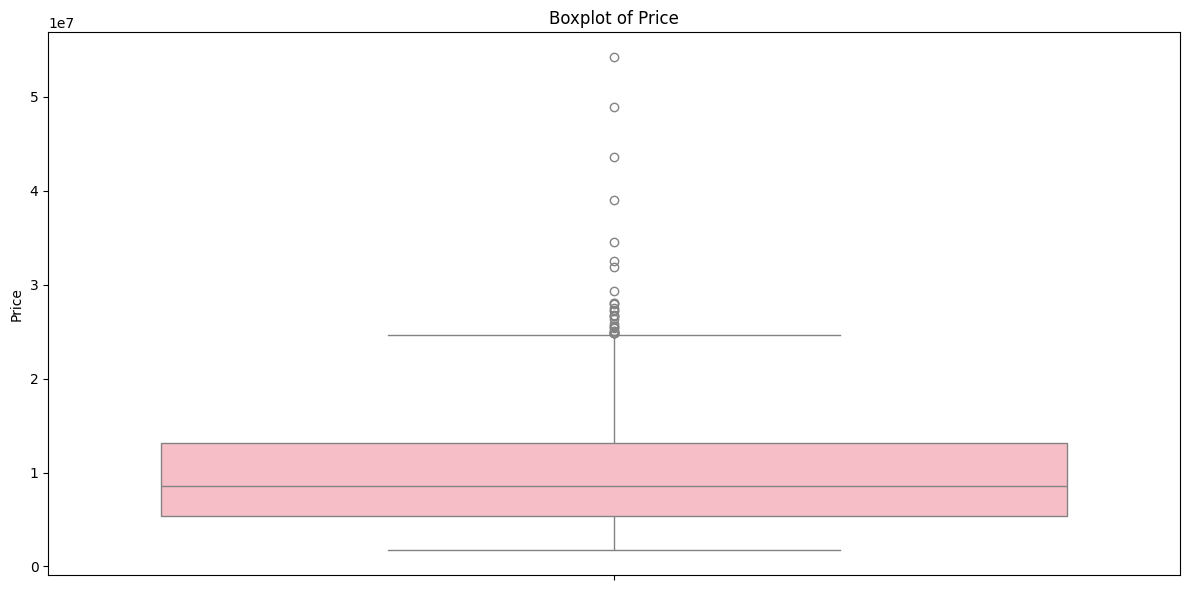

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#box plot to check for outliers in numerical features
numerical_columns = ['Price']

plt.figure(figsize=(12, 6))
for i, column in enumerate(numerical_columns, 1):
    plt.subplot(1, len(numerical_columns), i)
    sns.boxplot(data_encoded[column], color='lightpink')
    plt.title(f'Boxplot of {column}')

plt.tight_layout()
plt.show()



As can be seen from above, the Price column contains outliers. When predicting with a dataset that contains outliers with the empirical study, it is likely thee mean squared error will be very high then, since the prices are also quite high and the data contains high outliers.

In [ ]:
from sklearn.preprocessing import StandardScaler
# Remove any non-numeric characters from Screen Size column
data_encoded['Screen Size'] = data_encoded['Screen Size'].replace({r'"': ''}, regex=True)

#Convert the 'Screen Size' column to numeric (float)
data_encoded['Screen Size'] = pd.to_numeric(data_encoded['Screen Size'], errors='coerce')  # 'coerce' will turn invalid parsing into NaN
data_encoded['Weight'] = data_encoded['Weight'].str.extract('(\d+\.\d+|\d+)').astype(float)

# Check if the conversion is successful
print(data_encoded['Screen Size'].head())
data_encoded = data_encoded.dropna()
#Select numerical features for LOF
numerical_features = ['Price', 'Screen Size']

#scale
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_encoded)

0    13.3
1    13.3
2    15.6
3    15.4
4    13.3
Name: Screen Size, dtype: float64


In [ ]:
from sklearn.neighbors import LocalOutlierFactor

# Apply LOF to detect outliers
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.01)  # Adjust contamination based on expected outliers

# Get LOF predictions (-1 = outlier, 1 = inlier)
outlier_labels = lof.fit_predict(data_scaled)

#outlier labels as a new column in the dataframe
data_encoded['LOF_Outlier'] = outlier_labels

outliers = data_encoded[data_encoded['LOF_Outlier'] == -1]
print("Detected Outliers:")
print(outliers)


Detected Outliers:
     Screen Size  Weight        Price  Manufacturer_Apple  Manufacturer_Asus  \
6           15.4    2.04  19028613.24                True              False   
50          10.1    0.69   2836548.00               False              False   
90          15.6    2.45   6215508.00               False               True   
127         14.0    1.65   2471887.08               False               True   
177         18.4    4.40  24888708.00               False              False   
387         15.6    2.23  12173148.00               False              False   
718         14.0    1.40   2356380.00               False              False   
794         12.0    0.92  10359180.00                True              False   
807         15.6    2.04   5593068.00               False              False   
945         15.6    2.50   8883108.00               False              False   

     Manufacturer_Chuwi  Manufacturer_Dell  Manufacturer_Fujitsu  \
6                 False         

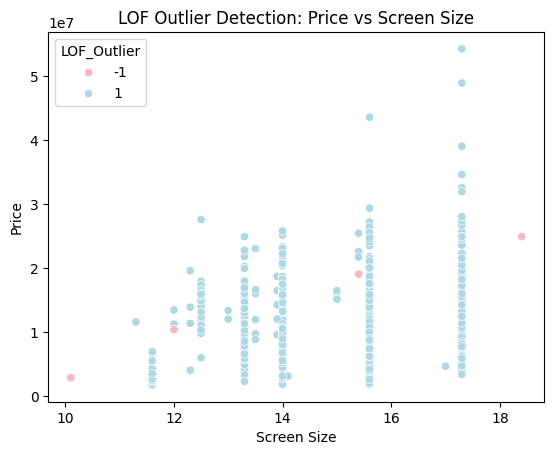

In [ ]:
# Visualizing the outliers (pink points = outliers, light blue points = inliers)
sns.scatterplot(x=data_encoded['Screen Size'], y=data_encoded['Price'], hue=data_encoded['LOF_Outlier'], palette={1: 'lightblue', -1: 'lightpink'})
plt.title('LOF Outlier Detection: Price vs Screen Size')
plt.show()

In [ ]:
data_cleaned = data_encoded[data_encoded['LOF_Outlier'] == 1].drop('LOF_Outlier', axis=1)  # Drop the LOF_Outlier column
print(data_encoded.shape)
print(data_cleaned.shape)
# Display the cleaned dataset - without outliers
data_cleaned.head()

(977, 804)
(967, 803)


,Screen Size,Weight,Price,Manufacturer_Apple,Manufacturer_Asus,Manufacturer_Chuwi,Manufacturer_Dell,Manufacturer_Fujitsu,Manufacturer_Google,Manufacturer_HP,...,GPU_Nvidia Quadro M620M,Operating System_Chrome OS,Operating System_Linux,Operating System_Mac OS,Operating System_No OS,Operating System_Windows,Operating System_macOS,Operating System Version_10 S,Operating System Version_7,Operating System Version_X
0,13.3,1.37,11912523.48,True,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1,13.3,1.34,7993374.48,True,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
2,15.6,1.86,5112900.00,False,False,False,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
3,15.4,1.83,22563005.40,True,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
4,13.3,1.37,16037611.20,True,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False


E. Predictive analysis: Linear regression

## 💻 D and E. Predictive analysis: Linear regression and Feature Engineering

In [ ]:
#helper func to create features:
def create_features(data):
    # Convert 'Weight' and 'Screen Size' to numeric if needed (in case they have non-numeric values)
    data['Weight'] = pd.to_numeric(data['Weight'], errors='coerce')
    data['Screen Size'] = pd.to_numeric(data['Screen Size'], errors='coerce')

    # Feature 2: Ratio of Weight to Screen Size
    data['Weight_to_ScreenSize_Ratio'] = data['Weight'] / data['Screen Size']

    # Feature 3: Squared Screen Size
    data['Screen_Size_Squared'] = data['Screen Size'] ** 2

    # Feature 4: Multiplying Weight and Screen Size
    data['Weight_ScreenSize_Interaction'] = data['Weight'] * data['Screen Size']

    return data


data_with_aggregation = create_features(data_encoded)
print(data_with_aggregation.head())


   Screen Size  Weight        Price  Manufacturer_Apple  Manufacturer_Asus  \
0         13.3    1.37  11912523.48                True              False   
1         13.3    1.34   7993374.48                True              False   
2         15.6    1.86   5112900.00               False              False   
3         15.4    1.83  22563005.40                True              False   
4         13.3    1.37  16037611.20                True              False   

   Manufacturer_Chuwi  Manufacturer_Dell  Manufacturer_Fujitsu  \
0               False              False                 False   
1               False              False                 False   
2               False              False                 False   
3               False              False                 False   
4               False              False                 False   

   Manufacturer_Google  Manufacturer_HP  ...  Operating System_No OS  \
0                False            False  ...                  

## 💻 F. Empirical Study


In [ ]:
# Define remove_outliers function
def remove_outliers(data, contamination=0.01, n_neighbors=20):
    """Removes outliers from the dataset using Local Outlier Factor (LOF)."""
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data.select_dtypes(include=[np.number]))
    lof = LocalOutlierFactor(n_neighbors=n_neighbors, contamination=contamination)
    outlier_labels = lof.fit_predict(data_scaled)
    return data[outlier_labels == 1]  # Keep only data points without outliers


# Assuming data_encoded is the dataset with outliers and without extra features but with one-hot encoding
D = data_encoded.copy()

# Split into DR and DT
DR, DT = train_test_split(D, test_size=0.2, random_state=42)

#Create experiments
experiments = {
    "baseline": DR.copy(),
    "outlier_removed": remove_outliers(DR.copy()),
    "feature_engineered": create_features(DR.copy()),
    "outlier_removed_and_feature_engineered": create_features(remove_outliers(DR.copy()))
}

# Do 4-fold Cross-Validation
cv_results = {}
kf = KFold(n_splits=4, shuffle=True, random_state=42)

for exp_name, DRX in experiments.items():
    X = DRX.drop(columns=['Price'])
    y = DRX['Price']

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    fold_scores = []
    for train_idx, val_idx in kf.split(X_scaled):
        X_train, X_val = X_scaled[train_idx], X_scaled[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = LinearRegression()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        fold_scores.append(r2_score(y_val, y_pred))

    cv_results[exp_name] = np.mean(fold_scores)

#get the best model
best_experiment = max(cv_results, key=cv_results.get)

#train on DR and Evaluate on DT
X_train = experiments[best_experiment].drop(columns=['Price'])
y_train = experiments[best_experiment]['Price']
X_test = DT.drop(columns=['Price'])
y_test = DT['Price']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

final_model = LinearRegression()
final_model.fit(X_train_scaled, y_train)
y_pred_test = final_model.predict(X_test_scaled)

test_r2 = r2_score(y_test, y_pred_test)

# Empirical Study results
print("\nEmpirical Study Results:")
for exp, score in cv_results.items():
    print(f"{exp}: R² = {score:.4f}")

#the test R²
print(f"\nTest R²: {test_r2:.4f}")





Empirical Study Results:
baseline: R² = -0.0027
outlier_removed: R² = 0.5803
feature_engineered: R² = -0.0027
outlier_removed_and_feature_engineered: R² = 0.5803

Test R²: 0.7694


]

## 💻 G. Results and Conclusion

During cross-validation, the models with outlier removal (R² = 0.5803) and feature aggregation (R² = -0.0027) performed moderately. However, when evaluated on the test set, the model achieved an R² score of 0.7694, which is a notable improvement.
This discrepancy between the cross-validation R² scores and the test R² score may suggest that the model generalizes well to unseen data. It could also indicate that the test set is easier to predict (e.g., it may contain fewer outliers or have better feature representations compared to the training set).

The feature engineered model performed the same as the baseline, which could be because there were so few numerical features in the dataset (the vast majority were just descriptions of the laptop) that proper additional features were hard to obtain, The greatest improvement in result came from removing the outliers, as was seen from the visulization of the price column beforehand.